In [18]:
from typing import TypedDict, Literal
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from langgraph.graph import StateGraph,START ,END
from pydantic import BaseModel , Field

In [19]:
from dotenv import load_dotenv
import os
load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: str | ForwardRef('os.PathLike[str]') | None = None, stream: IO[str] | None = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: str | None = 'utf-8') -> bool>

In [20]:
HUGGINGFACEHUB_API_TOKEN = os.getenv('HUGGINGFACEHUB_API_TOKEN')

In [21]:
llm = HuggingFaceEndpoint(
    repo_id='meta-llama/Llama-3.1-8B-Instruct',
    task='text-generation',
    huggingfacehub_api_token= HUGGINGFACEHUB_API_TOKEN
)

model = ChatHuggingFace(llm = llm)

In [22]:
class SentimentStructure(BaseModel):
    sentiment : Literal['positive','negative'] = Field(description='Sentiment of the review')

In [23]:
schema = SentimentStructure.model_json_schema()

structured_model = model.with_structured_output(
    schema,
    method="json_schema"
)

In [24]:
class State(TypedDict):
    user_response:str
    sentiment:str
    reply:str

In [30]:
def sentiment(state:State):
    user_response = state['user_response']

    prompt = f'What is the sentiment of the given response? - {user_response}'

    sentiment = structured_model.invoke(prompt)
    
    return {'sentiment':sentiment['sentiment']}

In [35]:
def positive_reply(state:State):
    user_response = state['user_response']
    prompt = f'write a positive response rely for the review - {user_response}'
    result = model.invoke(prompt).content

    return {'reply':result}

def negative_reply(state:State):
    user_response = state['user_response']
    prompt = f'write a negative response rely for the review - {user_response}'
    result = model.invoke(prompt).content

    return {'reply':result}

def check_condition(state:State) -> Literal['Positive_reply','Negative_reply']:

    sentiment = state['sentiment']

    if (sentiment == 'positive'):
        return 'Positive_reply'
    else:
        return 'Negative_reply'

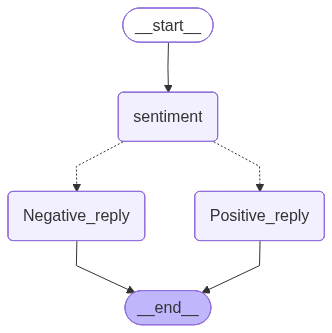

In [36]:
graph = StateGraph(State)

graph.add_node('sentiment',sentiment)

graph.add_node('Positive_reply',positive_reply)
graph.add_node('Negative_reply',negative_reply)

graph.add_edge(START, 'sentiment' )
graph.add_conditional_edges('sentiment',check_condition)
graph.add_edge('Positive_reply',END)
graph.add_edge('Negative_reply',END)

workflow = graph.compile()

workflow

In [39]:
inital_state = {
    'user_response':"This is the best product i have ever bought."
}
final_state = workflow.invoke(inital_state)
print(final_state)

{'user_response': 'This is the best product i have ever bought.', 'sentiment': 'positive', 'reply': 'Here’s a warm and positive response you could use:\n\n**"Thank you so much for your wonderful review! We’re absolutely thrilled to hear that you love the product—it means the world to us. Your happiness is our top priority, and we can’t wait to see how it continues to serve you well. Happy shopping, and we’d love to see you again soon! 😊"**\n\nThis keeps it uplifting, appreciative, and encourages future engagement.'}


In [40]:
final_state['reply']

'Here’s a warm and positive response you could use:\n\n**"Thank you so much for your wonderful review! We’re absolutely thrilled to hear that you love the product—it means the world to us. Your happiness is our top priority, and we can’t wait to see how it continues to serve you well. Happy shopping, and we’d love to see you again soon! 😊"**\n\nThis keeps it uplifting, appreciative, and encourages future engagement.'